# IA340 Mini Project
**Project Title:** Location and Frequency of Border Crossings into the United States

## Research Questions¶
## #1: 
Where are the most border crossings into the U.S.?
## #2: 
When did the most border crossings occur?
## #3: 
Which border experiences the highest amount of crossings?

## Dataset Documentation
**Source:** https://catalog.data.gov/dataset/border-crossing-entry-data-683ae

**Description:** "The Bureau of Transportation Statistics (BTS) Border Crossing Data provide summary statistics for inbound crossings at the U.S.-Canada and the U.S.-Mexico border at the port level. Data are available for trucks, trains, containers, buses, personal vehicles, passengers, and pedestrians. Border crossing data are collected at ports of entry by U.S. Customs and Border Protection (CBP). The data reflect the number of vehicles, containers, passengers or pedestrians entering the United States. CBP does not collect comparable data on outbound crossings. Users seeking data on outbound counts may therefore want to review data from individual bridge operators, border state governments, or the Mexican and Canadian governments."

**Time Period:** 1996-2025

**Reason For Choice:** This dataset is a good choice for studying border crossings because it provides detailed, time-based records of entry points, transportation types, and traffic volumes, offering insight into patterns of movement that are crucial for understanding economic activity, security management, and immigration challenges at U.S. borders.

### Necessary Imports

In [1]:
import warnings
warnings.simplefilter('ignore')

import pandas as pd
import matplotlib.pyplot as plt

### Read the Dataset and Display top 5 rows

In [2]:
bc_data = pd.read_csv("s3://ia340-fall2025-clark4jw-sldfkjsalgjsdoh/Border_Crossing_Entry_Data.csv")
bc_data.head()

,Port Name,State,Port Code,Border,Date,Measure,Value,Latitude,Longitude,Point
0,Jackman,Maine,104,US-Canada Border,Jan 2024,Trucks,6556,45.806,-70.397,POINT (-70.396722 45.805661)
1,Porthill,Idaho,3308,US-Canada Border,Apr 2024,Trucks,98,49.000,-116.499,POINT (-116.49925 48.999861)
2,San Luis,Arizona,2608,US-Mexico Border,Apr 2024,Buses,10,32.485,-114.782,POINT (-114.7822222 32.485)
3,Willow Creek,Montana,3325,US-Canada Border,Jan 2024,Pedestrians,2,49.000,-109.731,POINT (-109.731333 48.999972)
4,Warroad,Minnesota,3423,US-Canada Border,Jan 2024,Personal Vehicle Passengers,9266,48.999,-95.377,POINT (-95.376555 48.999)


In [3]:
# Ensure Date column is datetime
bc_data['Date'] = pd.to_datetime(bc_data['Date'], format='%b %Y', errors='coerce')

# Extract and sort unique years
years = sorted(bc_data['Date'].dt.year.dropna().unique())

print(f"Years covered in dataset: {years[0]} to {years[-1]}")
print("All unique years present:", years)

Years covered in dataset: 1996 to 2025
All unique years present: [1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


In [4]:
bc_data.describe

<bound method NDFrame.describe of            Port Name      State  Port Code            Border       Date  \
0            Jackman      Maine        104  US-Canada Border 2024-01-01   
1           Porthill      Idaho       3308  US-Canada Border 2024-04-01   
2           San Luis    Arizona       2608  US-Mexico Border 2024-04-01   
3       Willow Creek    Montana       3325  US-Canada Border 2024-01-01   
4            Warroad  Minnesota       3423  US-Canada Border 2024-01-01   
...              ...        ...        ...               ...        ...   
403852        Norton    Vermont        211  US-Canada Border 2025-08-01   
403853     Limestone      Maine        118  US-Canada Border 2025-08-01   
403854   Trout River   New York        715  US-Canada Border 2025-08-01   
403855       El Paso      Texas       2402  US-Mexico Border 2025-08-01   
403856        Calais      Maine        115  US-Canada Border 2025-08-01   

                            Measure  Value  Latitude  Longitude  

In [5]:
#Changing the date column format
bc_data['Date'] = pd.to_datetime(bc_data['Date'], format='%b %Y')

In [6]:
# --------------------------------------------
# Border Crossing Data Cleaning & Analysis
# --------------------------------------------

import pandas as pd
import numpy as np

# --------------------------------------------
# CLEAN
# --------------------------------------------

# 1. Basic profile
print("=== BASIC DATA PROFILE ===")
print(bc_data.info())
print("\n=== DESCRIPTIVE STATISTICS ===")
print(bc_data.describe(include='all'))

# 2. Handle missing values
# Check for missing data
print("\n=== MISSING VALUES ===")
print(bc_data.isnull().sum())

# If missing numeric values in 'Value', fill with 0 (assume missing counts = 0)
bc_data['Value'] = bc_data['Value'].fillna(0)

# Drop rows missing essential information like Port Name, Border, or Date
bc_data = bc_data.dropna(subset=['Port Name', 'Border', 'Date'])

# 3. Remove duplicates (if any)
before = len(bc_data)
bc_data = bc_data.drop_duplicates()
after = len(bc_data)
print(f"\nRemoved {before - after} duplicate rows.")

# 4. Fix data types
# Convert 'Date' to datetime
bc_data['Date'] = pd.to_datetime(bc_data['Date'], format='%b %Y', errors='coerce')

# Ensure 'Value' is numeric
bc_data['Value'] = pd.to_numeric(bc_data['Value'], errors='coerce')

# 5. Check for validity
# Example: Ensure all Values are non-negative
invalid_values = bc_data[bc_data['Value'] < 0]
if len(invalid_values) > 0:
    print(f"Found {len(invalid_values)} invalid negative Value entries. Setting to NaN.")
    bc_data.loc[bc_data['Value'] < 0, 'Value'] = np.nan

# Replace any new NaN Values with 0
bc_data['Value'] = bc_data['Value'].fillna(0)

# 6. Document changes
print("\n=== CLEANING SUMMARY ===")
print("• Missing values handled (filled or dropped where critical).")
print("• Duplicates removed.")
print("• Date parsed into datetime format.")
print("• Negative or invalid values corrected.")
print("• Dataset ready for aggregation and analysis.\n")

# --------------------------------------------
# PROCESS / AGGREGATE
# --------------------------------------------

# Create a new variable: total crossings per state
state_crossings = bc_data.groupby('State')['Value'].sum().reset_index()
state_crossings = state_crossings.sort_values(by='Value', ascending=False)

# Explain why:
print("New variable 'state_crossings' shows which U.S. states have the highest total entries.")
print("This supports the research question: 'Where are the most border crossings into the U.S.?'\n")

print(state_crossings.head())

# --------------------------------------------
# QUERY
# --------------------------------------------

# Example query: Find all border crossings in 2024 above 1 million
filtered_2024 = bc_data[
    (bc_data['Date'].dt.year == 2024) & 
    (bc_data['Value'] > 1_000_000)
]

print("\n=== QUERY: Border Crossings > 1 Million in 2024 ===")
print(filtered_2024.head())

# Show results in a DataFrame
filtered_2024_summary = filtered_2024.groupby(['Port Name', 'Border'])['Value'].sum().reset_index()
filtered_2024_summary = filtered_2024_summary.sort_values(by='Value', ascending=False)
print("\nFiltered summary (top crossings > 1M in 2024):")
print(filtered_2024_summary.head())


=== BASIC DATA PROFILE ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 403857 entries, 0 to 403856
Data columns (total 10 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Port Name  403857 non-null  object        
 1   State      403853 non-null  object        
 2   Port Code  403857 non-null  int64         
 3   Border     403857 non-null  object        
 4   Date       403857 non-null  datetime64[ns]
 5   Measure    403857 non-null  object        
 6   Value      403857 non-null  int64         
 7   Latitude   403853 non-null  float64       
 8   Longitude  403853 non-null  float64       
 9   Point      403853 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(2), object(5)
memory usage: 30.8+ MB
None

=== DESCRIPTIVE STATISTICS ===
       Port Name         State      Port Code            Border  \
count     403857        403853  403857.000000            403857   
unique       117            14   

# Question 1: Where are the most border crossings into the US?

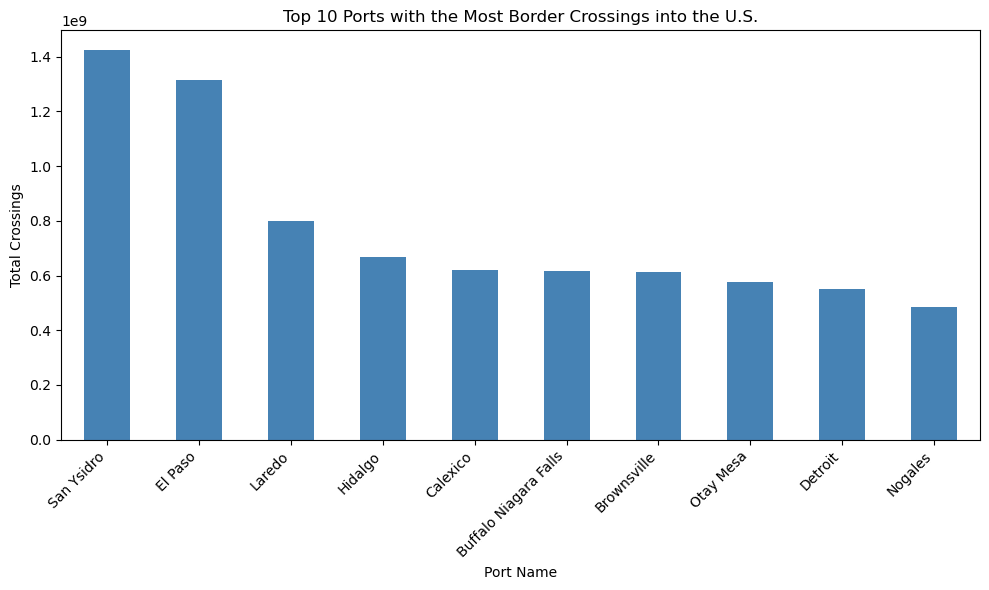

In [7]:
top_ports = bc_data.groupby('Port Name')['Value'].sum().nlargest(10)

plt.figure(figsize=(10,6))
top_ports.plot(kind='bar', color='steelblue')
plt.title("Top 10 Ports with the Most Border Crossings into the U.S.")
plt.xlabel("Port Name")
plt.ylabel("Total Crossings")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Explanation

The highest number of border crossings occurs in San Ysidro port and El Paso port, with various other ports experiencing heavy border crossings in Laredo, Hidalgo, Calexico, Niagra Falls, Brownsville, Otay Mesa, Detroit, and Nogales.

# Question 2: When did the most border crossings occur?

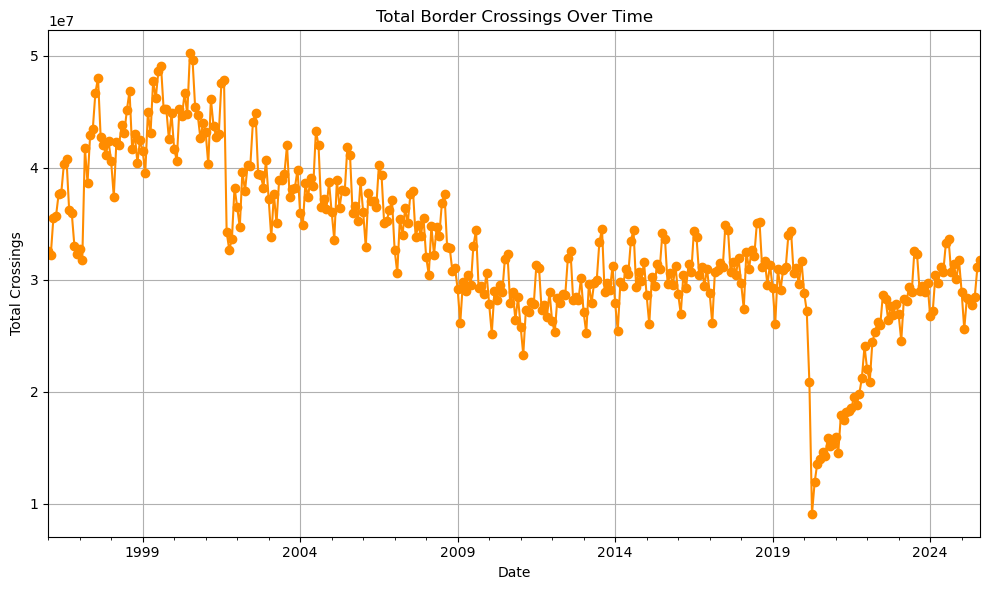

In [8]:
crossings_over_time = bc_data.groupby('Date')['Value'].sum()

plt.figure(figsize=(10,6))
crossings_over_time.plot(kind='line', marker='o', color='darkorange')
plt.title("Total Border Crossings Over Time")
plt.xlabel("Date")
plt.ylabel("Total Crossings")
plt.grid(True)
plt.tight_layout()
plt.show()

### Explanation

At its peak, the most border crossings occurred around 2001/2002, with a slow dip until 2011. Then, in 2020 there was a massive decrease in border crossings, most likely due to the change in administration, with this number increasing until present day.

# Question 3: Which border experiences the highest amount of crossings?

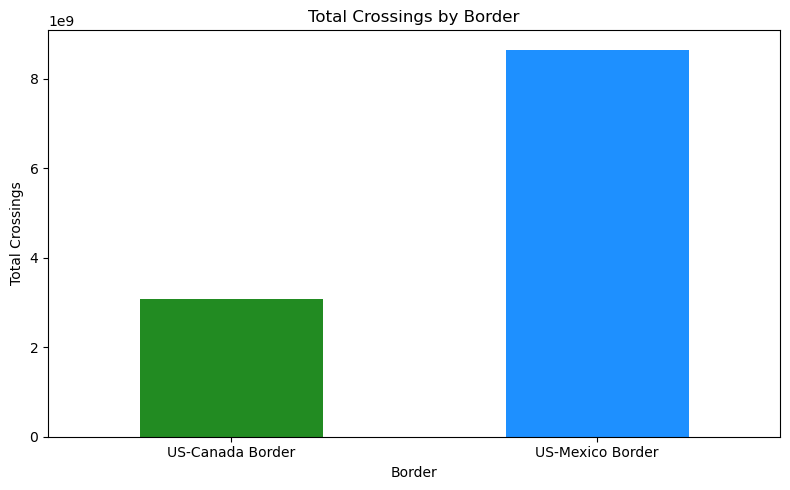

Total Crossings by Border:
Border
US-Canada Border    3084701112
US-Mexico Border    8650701394
Name: Value, dtype: int64


In [9]:
crossings_by_border = bc_data.groupby('Border')['Value'].sum()

plt.figure(figsize=(8,5))
crossings_by_border.plot(kind='bar', color=['forestgreen', 'dodgerblue'])
plt.title("Total Crossings by Border")
plt.xlabel("Border")
plt.ylabel("Total Crossings")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Print summary totals for clarity
print("Total Crossings by Border:")
print(crossings_by_border)

### Explanation

The border with the highest number of crossings is by far the US-Mexico border, which has about 2.5x the number of crossings that the US-Canada border does

# End of Project